패턴매칭을 이용하여 텐서 표현을 간단화 시킨다. 옵션으로는 `HeadQs`와 `CovDs`가 있다.

## 0. 설정

In [1]:
<< mTensor`

In [2]:
$PreRead = 
  ReplaceAll[#, 
    expr_String :> StringReplace[expr,
    "TMP" -> "mTensor`Private"]] &;

In [3]:
DefineKind[Alphabet["Greek"], Greek];
DefineKind[ToUpperCase /@ Alphabet[], Capital]

In [5]:
Tdefine[T, "*"];
Tdefine[f[]]; Tdefine[v, "a"];
Tdefine[A, "-ba"]; Tdefine[B, "ab"];
Tdefine[S, "ba"]; Tdefine[F, "-ba"]

## 1. Single Terms

### 1.1 Single Tensor

In [9]:
{A[la, ua], A[1, 1], A[-1, 1]} // TsimplifyPatternMatching

{0, 0, A[-1, 1]}

In [10]:
{BD[la, lb, A[ua, ub]], BD[la, ub, A[ua, lb]]}

{BD[la, BD[lb, A[ua, ub]]], BD[la, BD[ub, A[ua, lb]]]}

In [11]:
% // TsimplifyPatternMatching

{0, BD[la, BD[ub, A[ua, lb]]]}

### 1.2 Two Tensors

In [12]:
A[la, lb] S[ua, ub]

A[la, lb] S[ua, ub]

In [13]:
% // TsimplifyPatternMatching

0

In [14]:
{S[la, lb]  BD[lc, A[ua, ub]], S[la, ub]  CD[lc, A[ua, lb]],
 S[la, ub]  BD[lc, A[ua, lb]]}

{BD[lc, A[ua, ub]] S[la, lb], CD[lc, A[ua, lb]] S[la, ub], BD[lc, A[ua, lb]] S[la, ub]}

In [15]:
% // TsimplifyPatternMatching

{0, 0, BD[lc, A[ua, lb]] S[la, ub]}

In [16]:
TorsionFreeQ[CD] = False;

In [17]:
{CD[la, lb, f[]] A[ua, ub], CD[la, lb, S[lc, ld]] A[ua, ub]}

{A[ua, ub] CD[la, CD[lb, f[]]], A[ua, ub] CD[la, CD[lb, S[lc, ld]]]}

In [18]:
% // TsimplifyPatternMatching

{A[la, lb] CD[ua, CD[ub, f[]]], A[la, lb] CD[ua, CD[ub, S[lc, ld]]]}

In [19]:
TorsionFreeQ[CD] = True;

In [20]:
%% // TsimplifyPatternMatching

{0, A[la, lb] CD[ua, CD[ub, S[lc, ld]]]}

In [21]:
{CD[la, ub, f[]] A[ua, lb], BD[lc, CD[la, ub, f[]]] A[ua, lb]}

{A[ua, lb] CD[la, CD[ub, f[]]], A[ua, lb] BD[lc, CD[la, CD[ub, f[]]]]}

In [22]:
% // TsimplifyPatternMatching

{0, A[ua, lb] BD[lc, CD[la, CD[ub, f[]]]]}

In [23]:
Off[CoordinateBasisFlag]

In [24]:
expr = {BD[la, lb, f[]] A[ua, ub],
         BD[la, lb, S[lc, ld]] A[ua, ub],
         BD[lc, ua, lb, S[ld, le]] A[la, ub],
         CD[lc, BD[ua, lb, S[ld, le]]] A[la, ub],
         CD[lc, BD[la, ub, S[ld, le]]] A[ua, lb]}

{A[ua, ub] BD[la, BD[lb, f[]]], A[ua, ub] BD[la, BD[lb, S[lc, ld]]], 
 
>   A[la, ub] BD[lc, BD[ua, BD[lb, S[ld, le]]]], 
 
>   A[la, ub] CD[lc, BD[ua, BD[lb, S[ld, le]]]], 
 
>   A[ua, lb] CD[lc, BD[la, BD[ub, S[ld, le]]]]}

In [25]:
expr // TsimplifyPatternMatching

{A[ua, ub] BD[la, BD[lb, f[]]], A[ua, ub] BD[la, BD[lb, S[lc, ld]]], 
 
>   A[la, ub] BD[lc, BD[ua, BD[lb, S[ld, le]]]], 
 
>   A[la, ub] CD[lc, BD[ua, BD[lb, S[ld, le]]]], 
 
>   A[ua, lb] CD[lc, BD[la, BD[ub, S[ld, le]]]]}

In [26]:
On[CoordinateBasisFlag]

In [27]:
expr // TsimplifyPatternMatching

{0, 0, A[la, ub] BD[lc, BD[ua, BD[lb, S[ld, le]]]], 
 
>   A[la, ub] CD[lc, BD[ua, BD[lb, S[ld, le]]]], 
 
>   A[ua, lb] CD[lc, BD[la, BD[ub, S[ld, le]]]]}

In [28]:
expr4 = expr[[4]]

A[la, ub] CD[lc, BD[ua, BD[lb, S[ld, le]]]]

In [29]:
PutMetric[expr4, ua]

A[la, ub] CD[lc, BD[lf, BD[lb, S[ld, le]]]] Metricg[ua, uf]

In [30]:
% // Absorbg

A[uf, ub] CD[lc, BD[lf, BD[lb, S[ld, le]]]]

In [31]:
% // TsimplifyPatternMatching

0

In [32]:
SetDefaultKind[Capital]

In [33]:
Off[CoordinateBasisFlag]

In [34]:
Tdefine[A[lA, lB], "-ba"]; Tdefine[S[lA, lB], "ba"]

In [35]:
{S[la, lb]  BD[lc, A[ua, ub]], S[lA, lB]  BD[lc, A[uA, uB]], 
 S[lA, lB]  BD[lC, A[uA, uB]]}

{BD[lc, A[ua, ub]] S[la, lb], BD[lc, A[uA, uB]] S[lA, lB], BD[lC, A[uA, uB]] S[lA, lB]}

In [36]:
TsimplifyPatternMatching[%]

{mTensor`Private`errObject[ErrorT[BD][lc, ErrorT[A][ua, ub]]] 
 
>    mTensor`Private`errObject[ErrorT[S][la, lb]], 0, 0}

In [37]:
{S[la, ub]  CD[lc, A[ua, lb]], S[la, uB]  CD[lc, A[ua, lB]], 
 S[la, uB]  CD[lC, A[ua, lB]], S[lA, uB]  CD[lC, A[uA, lB]]}

{CD[lc, A[ua, lb]] S[la, ub], CD[lc, A[ua, lB]] S[la, uB], CD[lC, A[ua, lB]] S[la, uB], 
 
>   CD[lC, A[uA, lB]] S[lA, uB]}

In [38]:
TsimplifyPatternMatching[%]

{mTensor`Private`errObject[ErrorT[CD][lc, A[ua, lb]]] 
 
>    mTensor`Private`errObject[ErrorT[S][la, ub]], 
 
>   mTensor`Private`errObject[ErrorT[CD][lc, A[ua, lB]]] 
 
>    mTensor`Private`errObject[ErrorT[S][la, uB]], 
 
>   mTensor`Private`errObject[ErrorT[CD][lC, ErrorT[A][ua, lB]]] 
 
>    mTensor`Private`errObject[ErrorT[S][la, uB]], 0}

In [39]:
{S[lA, uB]  CD[lc, A[uA, lB]], S[lA, uB]  CD[lC, A[uA, lB]], 
 S[lA, uB]  BD[lc, A[uA, lB]]}

{CD[lc, A[uA, lB]] S[lA, uB], CD[lC, A[uA, lB]] S[lA, uB], BD[lc, A[uA, lB]] S[lA, uB]}

In [40]:
TsimplifyPatternMatching[%]

{mTensor`Private`errObject[ErrorT[CD][lc, A[uA, lB]]] S[lA, uB], 0, 
 
>   BD[lc, A[uA, lB]] S[lA, uB]}

In [41]:
{CD[la, lb, f[]] A[ua, ub], CD[lA, lB, f[]] A[uA, uB]}

{A[ua, ub] CD[la, CD[lb, f[]]], A[uA, uB] CD[lA, CD[lB, f[]]]}

In [42]:
TsimplifyPatternMatching[%]

{mTensor`Private`errObject[ErrorT[A][ua, ub]] 
 
>    mTensor`Private`errObject[ErrorT[CD][la, CD[lb, f[]]]], 0}

In [43]:
{CD[la, ub, f[]] A[ua, lb], CD[la, uB, f[]] A[ua, lB]}

{A[ua, lb] CD[la, CD[ub, f[]]], A[ua, lB] CD[la, CD[uB, f[]]]}

In [44]:
TsimplifyPatternMatching[%]

{mTensor`Private`errObject[ErrorT[A][ua, lb]] 
 
>    mTensor`Private`errObject[ErrorT[CD][la, CD[ub, f[]]]], 
 
>   mTensor`Private`errObject[ErrorT[A][ua, lB]] 
 
>    mTensor`Private`errObject[ErrorT[CD][la, CD[uB, f[]]]]}

In [45]:
{CD[lA, uB, f[]] A[uA, lB], BD[lc, CD[lA, uB, f[]]] A[uA, lB]}

{A[uA, lB] CD[lA, CD[uB, f[]]], A[uA, lB] BD[lc, CD[lA, CD[uB, f[]]]]}

In [46]:
TsimplifyPatternMatching[%]

{0, A[uA, lB] BD[lc, CD[lA, CD[uB, f[]]]]}

In [47]:
{BD[la, lb, S[lc, ld]] A[ua, ub],
 BD[lA, lB, S[lc, ld]] A[uA, uB], 
 BD[lA, lB, S[lC, lD]] A[uA, uB]}

{A[ua, ub] BD[la, BD[lb, S[lc, ld]]], A[uA, uB] BD[lA, BD[lB, S[lc, ld]]], 
 
>   A[uA, uB] BD[lA, BD[lB, S[lC, lD]]]}

In [48]:
TsimplifyPatternMatching[%]

{mTensor`Private`errObject[ErrorT[A][ua, ub]] 
 
>    mTensor`Private`errObject[ErrorT[BD][la, ErrorT[BD][lb, ErrorT[S][lc, ld]]]], 
 
>   A[uA, uB] mTensor`Private`errObject[ErrorT[BD][lA, 
 
>      ErrorT[BD][lB, ErrorT[S][lc, ld]]]], A[uA, uB] BD[lA, BD[lB, S[lC, lD]]]}

In [49]:
On[CoordinateBasisFlag]

In [50]:
{BD[la, lb, S[lc, ld]] A[ua, ub],
 BD[lA, lB, S[lc, ld]] A[uA, uB], 
 BD[lA, lB, S[lC, lD]] A[uA, uB]}

{A[ua, ub] BD[la, BD[lb, S[lc, ld]]], A[uA, uB] BD[lA, BD[lB, S[lc, ld]]], 
 
>   A[uA, uB] BD[lA, BD[lB, S[lC, lD]]]}

In [51]:
TsimplifyPatternMatching[%]

{mTensor`Private`errObject[ErrorT[A][ua, ub]] 
 
>    mTensor`Private`errObject[ErrorT[BD][la, ErrorT[BD][lb, ErrorT[S][lc, ld]]]], 
 
>   A[uA, uB] mTensor`Private`errObject[ErrorT[BD][lA, 
 
>      ErrorT[BD][lB, ErrorT[S][lc, ld]]]], 0}

In [52]:
{BD[ua, lb, S[lc, ld]] A[la, ub],
 BD[ua, lB, S[lc, ld]] A[la, uB]}

{A[la, ub] BD[ua, BD[lb, S[lc, ld]]], A[la, uB] BD[ua, BD[lB, S[lc, ld]]]}

In [53]:
TsimplifyPatternMatching[%]

{mTensor`Private`errObject[ErrorT[A][la, ub]] 
 
>    mTensor`Private`errObject[ErrorT[BD][ua, ErrorT[BD][lb, ErrorT[S][lc, ld]]]], 
 
>   mTensor`Private`errObject[ErrorT[A][la, uB]] 
 
>    mTensor`Private`errObject[ErrorT[BD][ua, ErrorT[BD][lB, ErrorT[S][lc, ld]]]]}

In [54]:
expr = {BD[uA, lB, S[lc, ld]] A[lA, uB],
         BD[uA, lB, S[lC, lD]] A[lA, uB],
         BD[lA, uB, S[lc, ld]] A[uA, lB]}

{A[lA, uB] BD[uA, BD[lB, S[lc, ld]]], A[lA, uB] BD[uA, BD[lB, S[lC, lD]]], 
 
>   A[uA, lB] BD[lA, BD[uB, S[lc, ld]]]}

In [55]:
TsimplifyPatternMatching[expr]

{A[lA, uB] mTensor`Private`errObject[ErrorT[BD][uA, ErrorT[BD][lB, ErrorT[S][lc, ld]]]], 
 
>   A[lA, uB] BD[uA, BD[lB, S[lC, lD]]], 
 
>   A[uA, lB] mTensor`Private`errObject[ErrorT[BD][lA, 
 
>      ErrorT[BD][uB, ErrorT[S][lc, ld]]]]}

In [56]:
expr2 = expr[[2]]

A[lA, uB] BD[uA, BD[lB, S[lC, lD]]]

In [57]:
PutMetric[expr2, uA]

A[lA, uB] BD[lE, BD[lB, S[lC, lD]]] Metricg[uA, uE]

In [58]:
% // Absorbg // TsimplifyPatternMatching

0

In [59]:
expr = {BD[la, BD[uA, lB, S[lc, ld]]] A[lA, uB], 
  CD[la, BD[uA, lB, S[lc, ld]]] A[lA, uB], 
  CD[la, BD[uA, lB, S[lC, lD]]] A[lA, uB], 
  CD[lE, BD[uA, lB, S[lC, lD]]] A[lA, uB]}

{A[lA, uB] BD[la, BD[uA, BD[lB, S[lc, ld]]]], 
 
>   A[lA, uB] CD[la, BD[uA, BD[lB, S[lc, ld]]]], 
 
>   A[lA, uB] CD[la, BD[uA, BD[lB, S[lC, lD]]]], 
 
>   A[lA, uB] CD[lE, BD[uA, BD[lB, S[lC, lD]]]]}

In [60]:
TsimplifyPatternMatching[expr]

{A[lA, uB] mTensor`Private`errObject[ErrorT[BD][la, 
 
>      ErrorT[BD][uA, ErrorT[BD][lB, ErrorT[S][lc, ld]]]]], 
 
>   A[lA, uB] mTensor`Private`errObject[ErrorT[CD][la, BD[uA, BD[lB, S[lc, ld]]]]], 
 
>   A[lA, uB] mTensor`Private`errObject[ErrorT[CD][la, BD[uA, BD[lB, S[lC, lD]]]]], 
 
>   A[lA, uB] CD[lE, BD[uA, BD[lB, S[lC, lD]]]]}

In [61]:
expr4 = expr[[4]]

A[lA, uB] CD[lE, BD[uA, BD[lB, S[lC, lD]]]]

In [62]:
PutMetric[expr4, uA] // Absorbg // TsimplifyPatternMatching

0

In [63]:
SetDefaultKind[Latin]  (* default *)

In [64]:
Tdefine[A, "-ba"]; Tdefine[S, "ba"]

### 1.3 Three Tensors

In [66]:
{A[ua, ub] v[la] v[lb],
 A[ua, lb] v[la] v[ub],
 A[ua, lb] v[la] CD[lc, v[ub]],
 A[ua, lb] CD[uc, v[la]] CD[lc, v[ub]]}

{A[ua, ub] v[la] v[lb], A[ua, lb] v[la] v[ub], A[ua, lb] CD[lc, v[ub]] v[la], 
 
>   A[ua, lb] CD[lc, v[ub]] CD[uc, v[la]]}

In [67]:
TsimplifyPatternMatching[%]

{0, 0, A[la, lb] CD[lc, v[ub]] v[ua], 0}

In [68]:
{A[la, lb] B[ua, lc] B[ub, uc], A[la, lb] B[ua, lc] B[ub, ud]}

{A[la, lb] B[ua, lc] B[ub, uc], A[la, lb] B[ua, lc] B[ub, ud]}

In [69]:
TsimplifyPatternMatching[%]

{0, A[la, lb] B[ua, lc] B[ub, ud]}

In [70]:
{A[la, lb] BD[ld, B[ua, lc]] BD[ud, B[ub, uc]], 
 A[la, lb] CD[ld, B[ua, lc]] CD[ud, B[ub, uc]], 
 A[la, lb] CD[ld, B[ua, lc]] B[ub, uc]}

{A[la, lb] BD[ld, B[ua, lc]] BD[ud, B[ub, uc]], 
 
>   A[la, lb] CD[ld, B[ua, lc]] CD[ud, B[ub, uc]], A[la, lb] B[ub, uc] CD[ld, B[ua, lc]]}

In [71]:
TsimplifyPatternMatching[%]

{A[la, lb] BD[ld, B[ua, lc]] BD[ud, B[ub, uc]], 0, A[la, lb] B[ub, lc] CD[ld, B[ua, uc]]}

In [72]:
{A[ua, lb] BD[la, f[]] BD[ub, f[]], 
 A[ua, ub] BD[la, v[lc]] BD[lb, v[uc]], 
 A[ua, ub] CD[la, v[lc]] CD[lb, v[uc]]}

{A[ua, lb] BD[la, f[]] BD[ub, f[]], A[ua, ub] BD[la, v[lc]] BD[lb, v[uc]], 
 
>   A[ua, ub] CD[la, v[lc]] CD[lb, v[uc]]}

In [73]:
TsimplifyPatternMatching[%]

{A[ua, lb] BD[la, f[]] BD[ub, f[]], A[ua, ub] BD[la, v[lc]] BD[lb, v[uc]], 0}

In [74]:
Tsimplify[%%] // ResetDummies

{0, A[ua, ub] BD[la, v[lc]] BD[lb, v[uc]], 0}

In [75]:
{A[ua, ub] BD[la, B[lc, ld]] BD[lb, B[uc, ud]], 
 A[ua, ub] CD[la, B[lc, ld]] CD[lb, B[uc, ud]], 
 A[ua, ub] CD[la, B[lc, ld]] CD[lb, B[ud, uc]]}

{A[ua, ub] BD[la, B[lc, ld]] BD[lb, B[uc, ud]], 
 
>   A[ua, ub] CD[la, B[lc, ld]] CD[lb, B[uc, ud]], 
 
>   A[ua, ub] CD[la, B[lc, ld]] CD[lb, B[ud, uc]]}

In [76]:
TsimplifyPatternMatching[%]

{A[ua, ub] BD[la, B[lc, ld]] BD[lb, B[uc, ud]], 0, 0}

In [77]:
{A[la, lb] CD[le, ua, B[lc, ld]] CD[lf, ub, B[uc, ud]], 
 A[la, lb] CD[le, ua, B[lc, ld]] CD[ue, ub, B[uc, ud]]}

{A[la, lb] CD[le, CD[ua, B[lc, ld]]] CD[lf, CD[ub, B[uc, ud]]], 
 
>   A[la, lb] CD[le, CD[ua, B[lc, ld]]] CD[ue, CD[ub, B[uc, ud]]]}

In [78]:
TsimplifyPatternMatching[%]

{A[la, lb] CD[le, CD[ua, B[lc, ld]]] CD[lf, CD[ub, B[uc, ud]]], 0}

In [79]:
{A[ua, ub] BD[la, Metricg[lc, ld]] BD[lb, Metricg[uc, ud]],
 A[ua, ub] CD[le, BD[la, Metricg[lc, ld]]] CD[ue, BD[lb, Metricg[uc, ud]]]}

{A[ua, ub] BD[la, Metricg[lc, ld]] BD[lb, Metricg[uc, ud]], 
 
>   A[ua, ub] CD[le, BD[la, Metricg[lc, ld]]] CD[ue, BD[lb, Metricg[uc, ud]]]}

In [80]:
TsimplifyPatternMatching[%]

{A[ua, ub] BD[la, Metricg[lc, ld]] BD[lb, Metricg[uc, ud]], 
 
>   A[ua, ub] CD[le, BD[la, Metricg[lc, ld]]] CD[ue, BD[lb, Metricg[uc, ud]]]}

In [81]:
TsimplifyPatternMatching[% /. BDinvgRule[]]

{0, 0}

In [82]:
{A[ua, ub] CD[le, BD[la, Metricg[lc, ld]]] CD[lf, 
   BD[lb, Metricg[uc, ud]]], 
 A[ua, ub] BD[le, BD[la, Metricg[lc, ld]]] BD[ue, 
   BD[lb, Metricg[uc, ud]]]}

{A[ua, ub] CD[le, BD[la, Metricg[lc, ld]]] CD[lf, BD[lb, Metricg[uc, ud]]], 
 
>   A[ua, ub] BD[le, BD[la, Metricg[lc, ld]]] BD[ue, BD[lb, Metricg[uc, ud]]]}

In [83]:
TsimplifyPatternMatching[%]

{A[ua, ub] CD[le, BD[la, Metricg[lc, ld]]] CD[lf, BD[lb, Metricg[uc, ud]]], 
 
>   A[ua, ub] BD[le, BD[la, Metricg[lc, ld]]] BD[ue, BD[lb, Metricg[uc, ud]]]}

## 2. Multi-Terms

In [84]:
{B[la, ua] + B[ua, la],
 CD[la, lb, B[ua, ub]] + CD[lc, ld, B[uc, ud]]}

{B[la, ua] + B[ua, la], CD[la, CD[lb, B[ua, ub]]] + CD[lc, CD[ld, B[uc, ud]]]}

In [85]:
TsimplifyPatternMatching[%]

{2 B[la, ua], 2 CD[la, CD[lb, B[ua, ub]]]}

In [86]:
{B[la, lb] B[ua, ub] + B[lc, ld] B[uc, ud], 
 B[la, lb] B[ub, ua] + B[la, lb] B[ua, ub], 
 B[lc, la] B[uc, lb] + B[lc, lb] B[uc, la]}

{B[la, lb] B[ua, ub] + B[lc, ld] B[uc, ud], B[la, lb] B[ua, ub] + B[la, lb] B[ub, ua], 
 
>   B[lc, lb] B[uc, la] + B[lc, la] B[uc, lb]}

In [87]:
TsimplifyPatternMatching[%]

{2 B[la, lb] B[ua, ub], B[la, lb] B[ua, ub] + B[la, lb] B[ub, ua], 2 B[lc, lb] B[uc, la]}

In [88]:
{S[la, uc] S[lc, lb] + S[le, la] S[lb, ue], 
 RiemannCD[la, lb, ld, le] S[ua, ue] + RiemannCD[lb, le, lc, ld] S[ue, uc]}

{S[la, uc] S[lc, lb] + S[lb, ue] S[le, la], 
 
>   RiemannCD[la, lb, ld, le] S[ua, ue] + RiemannCD[lb, le, lc, ld] S[ue, uc]}

In [89]:
TsimplifyPatternMatching[%]

{2 S[la, lc] S[uc, lb], 2 RiemannCD[la, lb, ld, le] S[ua, ue]}

In [90]:
CD[la, lb, F[ua, ub]]

CD[la, CD[lb, F[ua, ub]]]

In [91]:
expr = CDtoGamma[CDtoGamma[%]]

BD[la, BD[lb, F[ua, ub]]] + BD[la, GammaCD[lb, lc, ub]] F[ua, uc] + 
 
>   BD[la, GammaCD[lb, lc, ua]] F[uc, ub] + BD[lb, F[uc, ub]] GammaCD[la, lc, ua] + 
 
>   BD[la, F[uc, ub]] GammaCD[lb, lc, ua] + BD[la, F[ua, uc]] GammaCD[lb, lc, ub] + 
 
>   F[uc, ub] GammaCD[la, ld, ua] GammaCD[lb, lc, ud] + 
 
>   F[uc, ud] GammaCD[la, lc, ua] GammaCD[lb, ld, ub]

In [92]:
TsimplifyPatternMatching[expr]

BD[la, GammaCD[lb, lc, ub]] F[ua, uc]

BD[la, Metricg[ub, ud]] BD[lb, Metricg[lc, ld]] F[ua, uc]
--------------------------------------------------------- + 
                            2
 
    BD[la, Metricg[ub, ud]] BD[lc, Metricg[lb, ld]] F[ua, uc]
>   --------------------------------------------------------- - 
                                2
 
    BD[la, Metricg[ub, ud]] BD[ld, Metricg[lb, lc]] F[ua, uc]
>   --------------------------------------------------------- + 
                                2
 
    BD[la, BD[lb, Metricg[lc, ld]]] F[ua, uc] Metricg[ub, ud]
>   --------------------------------------------------------- + 
                                2
 
    BD[la, BD[lc, Metricg[lb, ld]]] F[ua, uc] Metricg[ub, ud]
>   --------------------------------------------------------- - 
                                2
 
    BD[la, BD[ld, Metricg[lb, lc]]] F[ua, uc] Metricg[ub, ud]
>   ---------------------------------------------------------
                                2
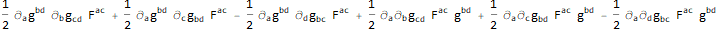

In [93]:
GammaToMetric[%]

BD[la, Metricg[ub, ud]] BD[lc, Metricg[lb, ld]] F[ua, uc]
---------------------------------------------------------
                            2
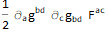

In [94]:
TsimplifyPatternMatching[%]

-(BD[la, Metricg[le, lf]] BD[lc, Metricg[lb, ld]] F[ua, uc] Metricg[ub, ue] 
 
>      Metricg[ud, uf]) / 2
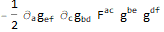

In [95]:
% /. BDinvgRule[]

In [96]:
TsimplifyPatternMatching[%]

0

In [97]:
expr = RiemannCD[la, lb, lc, ld] RiemannCD[le, lf, uc, ud] RiemannCD[
    ua, ub, ue, uf] + 
  RiemannCD[lc, ld, ug, uh] RiemannCD[le, lf, lg, lh] RiemannCD[uc, 
    ud, ue, uf]

RiemannCD[la, lb, lc, ld] RiemannCD[le, lf, uc, ud] RiemannCD[ua, ub, ue, uf] + 
 
>   RiemannCD[lc, ld, ug, uh] RiemannCD[le, lf, lg, lh] RiemannCD[uc, ud, ue, uf]

In [98]:
Timing[TsimplifyPatternMatching[expr]]  (* long evaluation *)

{9.48438, 2 RiemannCD[la, lb, lc, ld] RiemannCD[le, lf, uc, ud] 
 
>    RiemannCD[ua, ub, ue, uf]}

In [99]:
Timing[Tsimplify[expr]] // ResetDummies

{0.015625, 2 RiemannCD[la, lb, lc, ld] RiemannCD[ua, ub, le, lf] 
 
>    RiemannCD[uc, ud, ue, uf]}

In [100]:
BD[ua, S[lb, la]] BD[ub, f[]] + BD[ub, S[lb, la]] BD[ua, f[]]

BD[ua, S[lb, la]] BD[ub, f[]] + BD[ua, f[]] BD[ub, S[lb, la]]

In [101]:
TsimplifyPatternMatching[%]

2 BD[ua, S[lb, la]] BD[ub, f[]]

In [102]:
BD[lf, Metricg[la, lc]] BD[lg, Metricg[lb, le]] Metricg[ud, 
   ug] Metricg[ue, uf] - 
 BD[lf, Metricg[lb, le]] BD[lg, Metricg[la, lc]] Metricg[ud, 
   uf] Metricg[ue, ug]

BD[lf, Metricg[la, lc]] BD[lg, Metricg[lb, le]] Metricg[ud, ug] Metricg[ue, uf] - 
 
>   BD[lf, Metricg[lb, le]] BD[lg, Metricg[la, lc]] Metricg[ud, uf] Metricg[ue, ug]

In [103]:
TsimplifyPatternMatching[%]

0

In [104]:
BD[lb, Metricg[la, lc]] BD[uc, f[]] Metricg[ua, ub] - 
 BD[uc, Metricg[lb, lc]] BD[ld, f[]] Metricg[ub, ud]

BD[lb, Metricg[la, lc]] BD[uc, f[]] Metricg[ua, ub] - 
 
>   BD[ld, f[]] BD[uc, Metricg[lb, lc]] Metricg[ub, ud]

In [105]:
% // Absorbg // TsimplifyPatternMatching

0

## 3. Antisymmetric metric

In [106]:
DefineMetric[Eps, "\[Epsilon]", Capital, -1]

In [107]:
On[CoordinateBasisFlag[Capital]]

In [108]:
Tdefine[Cf[], "f", Capital]; Tdefine[Cv[lA], "v", "a"];
Tdefine[CA[lA, lB], "A", "-ba"]; Tdefine[CB[lA, lB], "B", "ab"];
Tdefine[CS[lA, lB], "S", "ba"]; Tdefine[CF[lA, lB], "F", "-ba"]

In [111]:
DefineDerivativeOperator[CovD, "D", Capital]

In [112]:
MakeMetricConnection[CovD, Eps]

In [113]:
CovD[lA, Eps[lB, lC]]

0

### 3.1 Single Tensor

In [114]:
{CA[lA, uA], CA[1, 1], CA[-1, 1]} // TsimplifyPatternMatching

{CA[lA, uA], 0, CA[-1, 1]}

In [115]:
{CS[lA, uA], CS[1, 1], CS[-1, 1]} // TsimplifyPatternMatching

{0, CS[1, 1], CS[-1, 1]}

In [116]:
{BD[lA, lB, CA[uA, uB]], BD[lA, uB, CA[uA, lB]]}

{BD[lA, BD[lB, CA[uA, uB]]], BD[lA, BD[uB, CA[uA, lB]]]}

In [117]:
% // TsimplifyPatternMatching

{0, BD[lA, BD[uB, CA[uA, lB]]]}

### 3.2 Two Tensors

In [118]:
CA[lA, lB] CS[uA, uB]

CA[lA, lB] CS[uA, uB]

In [119]:
TsimplifyPatternMatching[%]

0

In [120]:
expr = {CS[lA, lB]  BD[lC, CA[uA, uB]],
         CS[lA, uB] CovD[lC, CA[uA, lB]],
         CS[lA, uB]  BD[lC, CA[uA, lB]]}

{BD[lC, CA[uA, uB]] CS[lA, lB], CovD[lC, CA[uA, lB]] CS[lA, uB], 
 
>   BD[lC, CA[uA, lB]] CS[lA, uB]}

In [121]:
TsimplifyPatternMatching[expr]

{0, 0, BD[lC, CA[uA, lB]] CS[lA, uB]}

In [122]:
TorsionFreeQ[CovD] = False;

In [123]:
expr = {CovD[lA, CovD[lB, Cf[]]] CA[uA, uB],
         CovD[lA, CovD[lB, CS[lC, lD]]] CA[uA, uB]}

{CA[uA, uB] CovD[lA, CovD[lB, Cf[]]], CA[uA, uB] CovD[lA, CovD[lB, CS[lC, lD]]]}

In [124]:
TsimplifyPatternMatching[expr]

{CA[lA, lB] CovD[uA, CovD[uB, Cf[]]], CA[lA, lB] CovD[uA, CovD[uB, CS[lC, lD]]]}

In [125]:
TorsionFreeQ[CovD] = True;

In [126]:
TsimplifyPatternMatching[expr]

{0, CA[lA, lB] CovD[uA, CovD[uB, CS[lC, lD]]]}

In [127]:
{CovD[lA, CovD[uB, Cf[]]] CA[uA, lB], 
 BD[lC, CovD[lA, uB, Cf[]]] CA[uA, lB]}

{CA[uA, lB] CovD[lA, CovD[uB, Cf[]]], BD[lC, CovD[lA, CovD[uB, Cf[]]]] CA[uA, lB]}

In [128]:
TsimplifyPatternMatching[%]

{0, BD[lC, CovD[lA, CovD[uB, Cf[]]]] CA[uA, lB]}

In [129]:
Off[CoordinateBasisFlag[Capital]]

In [130]:
expr = {BD[lA, lB, Cf[]] CA[uA, uB],
         BD[lA, lB, CS[lC, lD]] CA[uA, uB],
         BD[lC, uA, lB, CS[lD, lE]] CA[lA, uB],
         CovD[lC, BD[uA, lB, CS[lD, lE]]] CA[lA, uB],
         CovD[lC, BD[lA, uB, CS[lD, lE]]] CA[uA, lB]}

{BD[lA, BD[lB, Cf[]]] CA[uA, uB], BD[lA, BD[lB, CS[lC, lD]]] CA[uA, uB], 
 
>   BD[lC, BD[uA, BD[lB, CS[lD, lE]]]] CA[lA, uB], 
 
>   CA[lA, uB] CovD[lC, BD[uA, BD[lB, CS[lD, lE]]]], 
 
>   CA[uA, lB] CovD[lC, BD[lA, BD[uB, CS[lD, lE]]]]}

In [131]:
TsimplifyPatternMatching[expr]

{BD[lA, BD[lB, Cf[]]] CA[uA, uB], BD[lA, BD[lB, CS[lC, lD]]] CA[uA, uB], 
 
>   BD[lC, BD[uA, BD[lB, CS[lD, lE]]]] CA[lA, uB], 
 
>   CA[lA, uB] CovD[lC, BD[uA, BD[lB, CS[lD, lE]]]], 
 
>   CA[uA, lB] CovD[lC, BD[lA, BD[uB, CS[lD, lE]]]]}

In [132]:
On[CoordinateBasisFlag[Capital]]

In [133]:
TsimplifyPatternMatching[expr]

{0, 0, BD[lC, BD[uA, BD[lB, CS[lD, lE]]]] CA[lA, uB], 
 
>   CA[lA, uB] CovD[lC, BD[uA, BD[lB, CS[lD, lE]]]], 
 
>   CA[uA, lB] CovD[lC, BD[lA, BD[uB, CS[lD, lE]]]]}

In [134]:
expr4 = expr[[4]]

CA[lA, uB] CovD[lC, BD[uA, BD[lB, CS[lD, lE]]]]

In [135]:
PutMetric[expr4, uA]

CA[lA, uB] CovD[lC, BD[lF, BD[lB, CS[lD, lE]]]] Eps[uA, uF]

In [136]:
Absorb[%, Eps]

-(CA[uF, uB] CovD[lC, BD[lF, BD[lB, CS[lD, lE]]]])

In [137]:
% // TsimplifyPatternMatching

0

### 3.3 Three Tensors

In [138]:
expr = {CA[uA, uB] Cv[lA] Cv[lB], CA[uA, lB] Cv[lA] Cv[uB],
         CA[uA, lB] Cv[lA] BD[lC, Cv[uB]],
         CA[uA, lB] CovD[uC, Cv[lA]] CovD[lC, Cv[uB]]}

{CA[uA, uB] Cv[lA] Cv[lB], CA[uA, lB] Cv[lA] Cv[uB], BD[lC, Cv[uB]] CA[uA, lB] Cv[lA], 
 
>   CA[uA, lB] CovD[lC, Cv[uB]] CovD[uC, Cv[lA]]}

In [139]:
TsimplifyPatternMatching[expr]

{0, 0, -(BD[lC, Cv[uB]] CA[lA, lB] Cv[uA]), 
 
>   -(CA[lA, lB] CovD[lC, Cv[uB]] CovD[uC, Cv[uA]])}

In [140]:
CS[uA, lB] CovD[uC, Cv[lA]] CovD[lC, Cv[uB]]

CovD[lC, Cv[uB]] CovD[uC, Cv[lA]] CS[uA, lB]

In [141]:
TsimplifyPatternMatching[%]

0

In [142]:
{CA[lA, lB] CB[uA, lC] CB[uB, uC],
 CA[lA, lB] CB[uA, lC] CB[uB, uD]}

{CA[lA, lB] CB[uA, lC] CB[uB, uC], CA[lA, lB] CB[uA, lC] CB[uB, uD]}

In [143]:
TsimplifyPatternMatching[%]

{CA[lA, lB] CB[uA, lC] CB[uB, uC], CA[lA, lB] CB[uA, lC] CB[uB, uD]}

In [144]:
{CS[lA, lB] CB[uA, lC] CB[uB, uC],
 CS[lA, lB] CB[uA, lC] CB[uB, uD]}

{CB[uA, lC] CB[uB, uC] CS[lA, lB], CB[uA, lC] CB[uB, uD] CS[lA, lB]}

In [145]:
TsimplifyPatternMatching[%]

{0, CB[lA, lC] CB[lB, uD] CS[uA, uB]}

In [146]:
{CA[lA, lB] BD[lD, CB[uA, lC]] BD[uD, CB[uB, uC]], 
 CA[lA, lB] CovD[lD, CB[uA, lC]] CovD[uD, CB[uB, uC]], 
 CA[lA, lB] CovD[lD, CB[uA, lC]] CB[uB, uC]}

{BD[lD, CB[uA, lC]] BD[uD, CB[uB, uC]] CA[lA, lB], 
 
>   CA[lA, lB] CovD[lD, CB[uA, lC]] CovD[uD, CB[uB, uC]], 
 
>   CA[lA, lB] CB[uB, uC] CovD[lD, CB[uA, lC]]}

In [147]:
TsimplifyPatternMatching[%]

{BD[lD, CB[uA, lC]] BD[uD, CB[uB, uC]] CA[lA, lB], 0, 
 
>   -(CA[lA, lB] CB[uB, lC] CovD[lD, CB[uA, uC]])}

In [148]:
{CA[uA, lB] BD[lA, Cf[]] BD[uB, Cf[]], 
 CA[uA, uB] BD[lA, Cv[lC]] BD[lB, Cv[uC]], 
 CA[uA, uB] CovD[lA, Cv[lC]] CovD[lB, Cv[uC]]}

{BD[lA, Cf[]] BD[uB, Cf[]] CA[uA, lB], BD[lA, Cv[lC]] BD[lB, Cv[uC]] CA[uA, uB], 
 
>   CA[uA, uB] CovD[lA, Cv[lC]] CovD[lB, Cv[uC]]}

In [149]:
TsimplifyPatternMatching[%]

{BD[lA, Cf[]] BD[uB, Cf[]] CA[uA, lB], BD[lA, Cv[lC]] BD[lB, Cv[uC]] CA[uA, uB], 
 
>   CA[lA, lB] CovD[uA, Cv[lC]] CovD[uB, Cv[uC]]}

In [150]:
{CS[uA, lB] BD[lA, Cf[]] BD[uB, Cf[]], 
 CS[uA, uB] BD[lA, Cv[lC]] BD[lB, Cv[uC]], 
 CS[uA, uB] CovD[lA, Cv[lC]] CovD[lB, Cv[uC]]}

{BD[lA, Cf[]] BD[uB, Cf[]] CS[uA, lB], BD[lA, Cv[lC]] BD[lB, Cv[uC]] CS[uA, uB], 
 
>   CovD[lA, Cv[lC]] CovD[lB, Cv[uC]] CS[uA, uB]}

In [151]:
TsimplifyPatternMatching[%]

{BD[lA, Cf[]] BD[uB, Cf[]] CS[uA, lB], BD[lA, Cv[lC]] BD[lB, Cv[uC]] CS[uA, uB], 0}

In [152]:
{CA[uA, uB] BD[lA, CB[lC, lD]] BD[lB, CB[uC, uD]], 
 CA[uA, uB] CovD[lA, CB[lC, lD]] CovD[lB, CB[uC, uD]], 
 CA[uA, uB] CovD[lA, CB[lC, lD]] CovD[lB, CB[uD, uC]]}

{BD[lA, CB[lC, lD]] BD[lB, CB[uC, uD]] CA[uA, uB], 
 
>   CA[uA, uB] CovD[lA, CB[lC, lD]] CovD[lB, CB[uC, uD]], 
 
>   CA[uA, uB] CovD[lA, CB[lC, lD]] CovD[lB, CB[uD, uC]]}

In [153]:
TsimplifyPatternMatching[%]

{BD[lA, CB[lC, lD]] BD[lB, CB[uC, uD]] CA[uA, uB], 0, 0}

In [155]:
{CA[lA, lB] CovD[lE, uA, CB[lC, lD]] CovD[lF, CovD[uB, CB[uC, uD]]], 
 CA[lA, lB] CovD[lE, CovD[uA, CB[lC, lD]]] CovD[uE, CovD[uB, CB[uC, uD]]]}

{CA[lA, lB] CovD[lE, CovD[uA, CB[lC, lD]]] CovD[lF, CovD[uB, CB[uC, uD]]], 
 
>   CA[lA, lB] CovD[lE, CovD[uA, CB[lC, lD]]] CovD[uE, CovD[uB, CB[uC, uD]]]}

In [156]:
TsimplifyPatternMatching[%]

{CA[lA, lB] CovD[lE, CovD[uA, CB[lC, lD]]] CovD[lF, CovD[uB, CB[uC, uD]]], 
 
>   CA[lA, lB] CovD[lE, CovD[uA, CB[lC, lD]]] CovD[uE, CovD[uB, CB[uC, uD]]]}

In [157]:
{CS[lA, lB] CovD[lE, uA, CB[lC, lD]] CovD[lF, CovD[uB, CB[uC, uD]]], 
 CS[lA, lB] CovD[lE, CovD[uA, CB[lC, lD]]] CovD[uE, CovD[uB, CB[uC, uD]]]}

{CovD[lE, CovD[uA, CB[lC, lD]]] CovD[lF, CovD[uB, CB[uC, uD]]] CS[lA, lB], 
 
>   CovD[lE, CovD[uA, CB[lC, lD]]] CovD[uE, CovD[uB, CB[uC, uD]]] CS[lA, lB]}

In [158]:
TsimplifyPatternMatching[%]

{CovD[lE, CovD[uA, CB[lC, lD]]] CovD[lF, CovD[uB, CB[uC, uD]]] CS[lA, lB], 0}

In [159]:
{CA[uA, uB] BD[lA, Eps[lC, lD]] BD[lB, Eps[uC, uD]],
 CA[uA, uB] CovD[lE, BD[lA, Eps[lC, lD]]] CovD[uE, BD[lB, Eps[uC, uD]]]}

{BD[lA, Eps[lC, lD]] BD[lB, Eps[uC, uD]] CA[uA, uB], 
 
>   CA[uA, uB] CovD[lE, BD[lA, Eps[lC, lD]]] CovD[uE, BD[lB, Eps[uC, uD]]]}

In [160]:
TsimplifyPatternMatching[%]

{BD[lA, Eps[lC, lD]] BD[lB, Eps[uC, uD]] CA[uA, uB], 
 
>   CA[uA, uB] CovD[lE, BD[lA, Eps[lC, lD]]] CovD[uE, BD[lB, Eps[uC, uD]]]}

In [161]:
%% /. BDinvgRule[Eps]

{-(BD[lA, Eps[lC, lD]] BD[lB, Eps[l!4, l!5]] CA[uA, uB] Eps[uC, u!4] Eps[uD, u!5]), 
 
>   -(CA[uA, uB] CovD[lE, BD[lA, Eps[lC, lD]]] CovD[uE, BD[lB, Eps[l!6, l!7]]] 
 
>      Eps[uC, u!6] Eps[uD, u!7])}

In [162]:
TsimplifyPatternMatching[%]

{0, -(CA[uA, uB] CovD[lE, BD[lA, Eps[lC, lD]]] CovD[uE, BD[lB, Eps[lF, lG]]] Eps[uC, uF] 
 
>      Eps[uD, uG])}

In [163]:
{CS[uA, uB] BD[lA, Eps[lC, lD]] BD[lB, Eps[uC, uD]],
 CS[uA, uB] CovD[lE, BD[lA, Eps[lC, lD]]] CovD[uE, BD[lB, Eps[uC, uD]]]}

{BD[lA, Eps[lC, lD]] BD[lB, Eps[uC, uD]] CS[uA, uB], 
 
>   CovD[lE, BD[lA, Eps[lC, lD]]] CovD[uE, BD[lB, Eps[uC, uD]]] CS[uA, uB]}

In [164]:
TsimplifyPatternMatching[%]

{BD[lA, Eps[lC, lD]] BD[lB, Eps[uC, uD]] CS[uA, uB], 
 
>   CovD[lE, BD[lA, Eps[lC, lD]]] CovD[uE, BD[lB, Eps[uC, uD]]] CS[uA, uB]}

In [165]:
%% /. BDinvgRule[Eps]

{-(BD[lA, Eps[lC, lD]] BD[lB, Eps[l!8, l!9]] CS[uA, uB] Eps[uC, u!8] Eps[uD, u!9]), 
 
>   -(CovD[lE, BD[lA, Eps[lC, lD]]] CovD[uE, BD[lB, Eps[l!10, l!11]]] CS[uA, uB] 
 
>      Eps[uC, u!10] Eps[uD, u!11])}

In [166]:
TsimplifyPatternMatching[%] 

{-(BD[lA, Eps[lC, lD]] BD[lB, Eps[lE, lF]] CS[uA, uB] Eps[uC, uE] Eps[uD, uF]), 0}

In [167]:
CA[uA, uB] CovD[lE, BD[lA, Eps[lC, lD]]] CovD[lF, BD[lB, Eps[uC, uD]]]

CA[uA, uB] CovD[lE, BD[lA, Eps[lC, lD]]] CovD[lF, BD[lB, Eps[uC, uD]]]

In [168]:
% /. BDinvgRule[Eps]

-(CA[uA, uB] CovD[lE, BD[lA, Eps[lC, lD]]] CovD[lF, BD[lB, Eps[lG, lH]]] Eps[uC, uG] 
 
>     Eps[uD, uH])

In [169]:
TsimplifyPatternMatching[%]

-(CA[uA, uB] CovD[lE, BD[lA, Eps[lC, lD]]] CovD[lF, BD[lB, Eps[lG, lH]]] Eps[uC, uG] 
 
>     Eps[uD, uH])

### 3.4 Multi-Terms

In [170]:
{CB[lA, uA] + CB[uA, lA], 
 CovD[lA, CovD[lB, CB[uA, uB]]] + CovD[lC, CovD[lD, CB[uC, uD]]]}

{CB[lA, uA] + CB[uA, lA], CovD[lA, CovD[lB, CB[uA, uB]]] + 
 
>    CovD[lC, CovD[lD, CB[uC, uD]]]}

In [171]:
TsimplifyPatternMatching[%]

{0, 2 CovD[lA, CovD[lB, CB[uA, uB]]]}

In [172]:
{CB[lA, lB] CB[uA, uB] + CB[lC, lD] CB[uC, uD], 
 CB[lA, lB] CB[uB, uA] + CB[lA, lB] CB[uA, uB], 
 CB[lC, lA] CB[uC, lB] + CB[lC, lB] CB[uC, lA]}

{CB[lA, lB] CB[uA, uB] + CB[lC, lD] CB[uC, uD], 
 
>   CB[lA, lB] CB[uA, uB] + CB[lA, lB] CB[uB, uA], 
 
>   CB[lC, lB] CB[uC, lA] + CB[lC, lA] CB[uC, lB]}

In [173]:
TsimplifyPatternMatching[%]

{2 CB[lA, lB] CB[uA, uB], CB[lA, lB] CB[uA, uB] + CB[lA, lB] CB[uB, uA], 0}

In [174]:
{CS[lA, uC] CS[lC, lB] + CS[lE, lA] CS[lB, uE], 
 RiemannCovD[lA, lB, lD, lE] CS[uA, uE] + 
  RiemannCovD[lB, lE, lC, lD] CS[uE, uC]}

{CS[lA, uC] CS[lC, lB] + CS[lB, uE] CS[lE, lA], 
 
>   CS[uA, uE] RiemannCovD[lA, lB, lD, lE] + CS[uE, uC] RiemannCovD[lB, lE, lC, lD]}

In [175]:
TsimplifyPatternMatching[%]

{0, 2 CS[lA, lE] RiemannCovD[uA, lB, lD, uE]}

In [176]:
expr = RiemannCovD[lA, lB, lC, lD] RiemannCovD[lE, lF, uC, 
    uD] RiemannCovD[uA, uB, uE, uF] + 
  RiemannCovD[lC, lD, uG, uH] RiemannCovD[lE, lF, lG, lH] RiemannCovD[
    uC, uD, uE, uF]

RiemannCovD[lA, lB, lC, lD] RiemannCovD[lE, lF, uC, uD] RiemannCovD[uA, uB, uE, uF] + 
 
>   RiemannCovD[lC, lD, uG, uH] RiemannCovD[lE, lF, lG, lH] RiemannCovD[uC, uD, uE, uF]

In [177]:
Timing[TsimplifyPatternMatching[expr]]  (* long evaluation *)

{9.98438, 2 RiemannCovD[lA, lB, lC, lD] RiemannCovD[lE, lF, uC, uD] 
 
>    RiemannCovD[uA, uB, uE, uF]}

In [178]:
Timing[ToCanonical[expr]]  // ResetDummies

{0.03125, 2 RiemannCovD[lA, lB, lC, lD] RiemannCovD[uA, uB, lE, lF] 
 
>    RiemannCovD[uC, uD, uE, uF]}

In [179]:
BD[uA, CS[lB, lA]] BD[uB, Cf[]] + BD[uB, CS[lB, lA]] BD[uA, Cf[]]

BD[uA, CS[lB, lA]] BD[uB, Cf[]] + BD[uA, Cf[]] BD[uB, CS[lB, lA]]

In [180]:
TsimplifyPatternMatching[%]

2 BD[uA, CS[lB, lA]] BD[uB, Cf[]]

In [181]:
BD[lF, Eps[lA, lC]] BD[lG, Eps[lB, lE]] Eps[uD, uG] Eps[uE, uF] - 
 BD[lF, Eps[lB, lE]] BD[lG, Eps[lA, lC]] Eps[uD, uF] Eps[uE, uG]

BD[lF, Eps[lA, lC]] BD[lG, Eps[lB, lE]] Eps[uD, uG] Eps[uE, uF] - 
 
>   BD[lF, Eps[lB, lE]] BD[lG, Eps[lA, lC]] Eps[uD, uF] Eps[uE, uG]

In [182]:
TsimplifyPatternMatching[%]

0

In [183]:
BD[lB, Eps[lA, lC]] BD[uC, Cf[]] Eps[uA, uB] - 
 BD[uC, Eps[lB, lC]] BD[lD, Cf[]] Eps[uB, uD]

BD[lB, Eps[lA, lC]] BD[uC, Cf[]] Eps[uA, uB] - 
 
>   BD[lD, Cf[]] BD[uC, Eps[lB, lC]] Eps[uB, uD]

In [184]:
% // TsimplifyPatternMatching

BD[lB, Eps[lA, lC]] BD[uC, Cf[]] Eps[uA, uB] - 
 
>   BD[lD, Cf[]] BD[uC, Eps[lB, lC]] Eps[uB, uD]

In [185]:
Absorb[%, Eps]

BD[uA, Eps[lA, lC]] BD[uC, Cf[]] - BD[uB, Cf[]] BD[uC, Eps[lB, lC]]

In [186]:
% // TsimplifyPatternMatching

2 BD[uA, Eps[lA, lC]] BD[uC, Cf[]]

## 문제점

In [187]:
expr = RiemannCD[la, lb, lc, ld] RiemannCD[le, lf, uc, ud] RiemannCD[
    ua, ub, ue, uf] + 
  RiemannCD[lc, ld, ug, uh] RiemannCD[le, lf, lg, lh] RiemannCD[uc, 
    ud, ue, uf]

RiemannCD[la, lb, lc, ld] RiemannCD[le, lf, uc, ud] RiemannCD[ua, ub, ue, uf] + 
 
>   RiemannCD[lc, ld, ug, uh] RiemannCD[le, lf, lg, lh] RiemannCD[uc, ud, ue, uf]

In [188]:
Timing[TsimplifyPatternMatching[expr]]  (* long evaluation *)

{9.64063, 2 RiemannCD[la, lb, lc, ld] RiemannCD[le, lf, uc, ud] 
 
>    RiemannCD[ua, ub, ue, uf]}

In [189]:
Timing[ToCanonical[expr]] // ResetDummies

{0.015625, 2 RiemannCD[la, lb, lc, ld] RiemannCD[ua, ub, le, lf] 
 
>    RiemannCD[uc, ud, ue, uf]}

In [190]:
Timing[Tsimplify[expr]] // ResetDummies

{0.015625, 2 RiemannCD[la, lb, lc, ld] RiemannCD[ua, ub, le, lf] 
 
>    RiemannCD[uc, ud, ue, uf]}